In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import netCDF4
import xarray as xr

In [2]:
ds = xr.open_dataset('data/bpeca550.nc')
ds

<xarray.Dataset> Size: 316kB
Dimensions:  (time: 26298)
Coordinates:
  * time     (time) datetime64[ns] 210kB 1950-01-01 1950-01-02 ... 2021-12-31
Data variables:
    rr       (time) float32 105kB ...
Attributes: (12/21)
    title:             
    description:       NIJMEGEN
    institution:       KNMI Climate Explorer and KNMI
    source_url:        http://www.ecad.eu/
    contact_email:     eca@knmi.nl
    reference:         Klein Tank et al. (2002) Daily dataset of 20th-century...
    ...                ...
    scripturl01:       http://climexp.knmi.nl/becaprcp.cgi?STATION=NIJMEGEN&W...
    timestamp:         Mon Oct  4 13:43:17 2021
    comment:           
    scripturl02:       http://climexp.knmi.nl/dat2nc.cgi?id=someone@somewhere...
    history:            2025-11-27  9:25:22 ./bin/dat2nc data/bpeca550.dat bp...
    Conventions:       CF-1.0

,time,rr
26293,2021-12-27,NaN
26294,2021-12-28,NaN
26295,2021-12-29,NaN
26296,2021-12-30,NaN
26297,2021-12-31,NaN


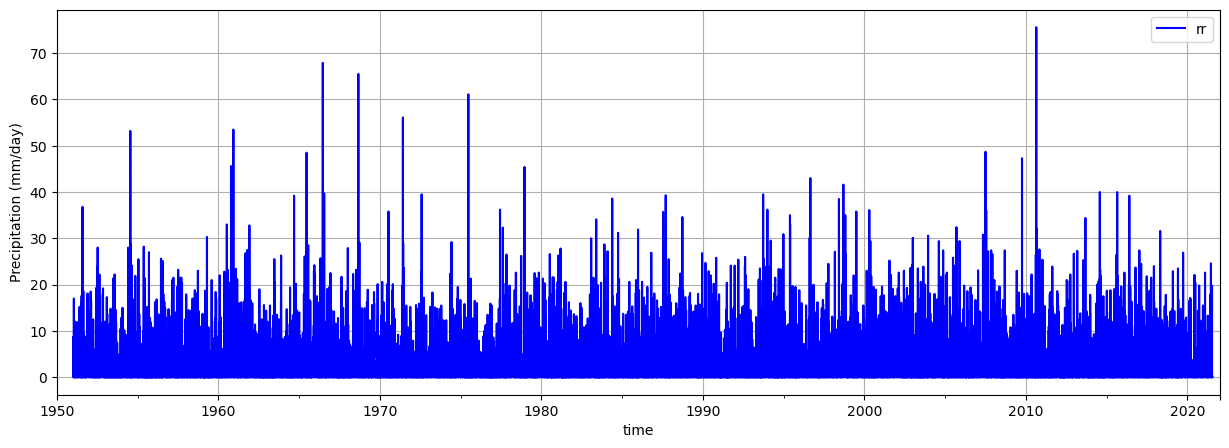

In [3]:
df = ds.to_dataframe().reset_index()
df.to_csv('data/precipitation.csv', index=False)


df.plot(x='time', y='rr', color='blue', figsize=(15,5))
plt.ylabel('Precipitation (mm/day)')
plt.grid()

display(df.tail())

In [4]:
zero_count = (df['rr'] == 0).sum()
NaN_count = df['rr'].isna().sum()
print(f"Number of zero values: {zero_count}")
print(f"Number of NaN values: {NaN_count}")

Number of zero values: 12150
Number of NaN values: 535


(array([5.30414916e-01, 7.24553305e-02, 4.30665613e-02, 3.29314406e-02,
        2.40285489e-02, 1.97465458e-02, 1.53721160e-02, 1.20450803e-02,
        8.04032215e-03, 6.59244805e-03, 6.19197692e-03, 4.62087480e-03,
        3.41944994e-03, 2.86494237e-03, 2.43366073e-03, 1.78673826e-03,
        1.35545661e-03, 1.44787410e-03, 1.04739829e-03, 4.00475816e-04,
        5.54505815e-04, 7.08534136e-04, 3.08058320e-04, 2.77252488e-04,
        1.54029160e-04, 1.54029393e-04, 9.24173561e-05, 1.54029393e-04,
        2.15640497e-04, 3.08058786e-05, 6.16115707e-05, 2.46447029e-04,
        0.00000000e+00, 3.08057854e-05, 3.08058786e-05, 0.00000000e+00,
        6.16117572e-05, 3.08057854e-05, 6.16117572e-05, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 6.16115707e-05, 0.00000000e+00,
        3.08057854e-05, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        3.08058786e-05, 0.00000000e+00, 0.00000000e+00, 3.08059719e-05,
        0.00000000e+00, 3.08057854e-05, 0.00000000e+00, 0.000000

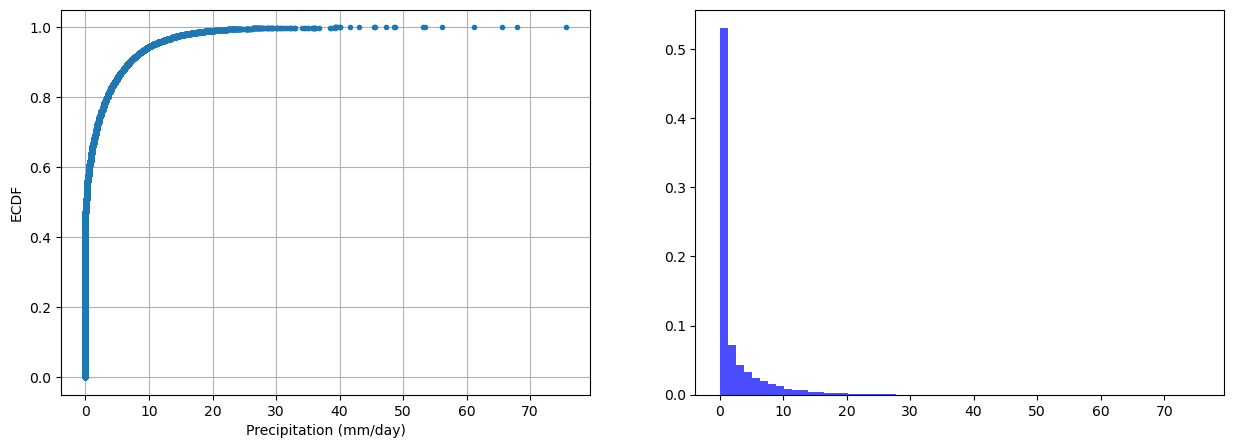

In [11]:
def ecdf(data):
    """ Compute ECDF """
    x = np.sort(data) #your code here #sorted data
    n = x.size
    y = np.arange(1, n+1) / n #your code here #non exceedance probabilities
    return(x,y)

x, y = ecdf(df['rr'].dropna())

plt.figure(figsize=(15,5))
plt.subplot(121)
plt.plot(x, y, marker='.', linestyle='none')
plt.xlabel('Precipitation (mm/day)')
plt.ylabel('ECDF')
plt.grid()

plt.subplot(122)
plt.hist(df['rr'].dropna(), bins=60, density=True, alpha=0.7, color='blue')


INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


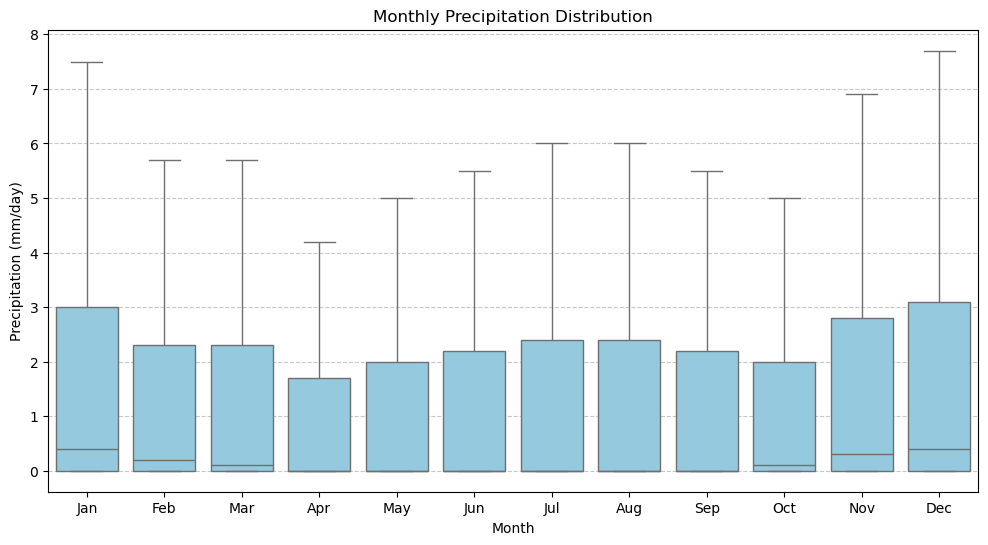

In [10]:
# 1. Ensure your 'time' column is in datetime format
df['time'] = pd.to_datetime(df['time'])

# 2. Extract the month (1=Jan, 12=Dec)
df['month'] = df['time'].dt.month

# 3. Plot
plt.figure(figsize=(12, 6))

# 'showfliers=False' hides the extreme outliers so you can see the boxes better. 
# Remove it if you want to see the extreme events.
sns.boxplot(x='month', y='rr', data=df, color='skyblue', showfliers=False)

# 4. Formatting
plt.title('Monthly Precipitation Distribution')
plt.ylabel('Precipitation (mm/day)')
plt.xlabel('Month')
plt.xticks(ticks=range(12), labels=['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
                                    'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()